# Minería de Datos y Modelización Predictiva
## Tarea final: Elecciones municipales en España

## 1. Introducción y objetivo del problema

El conjunto de datos `DatosEleccionesEspaña.xlsx` contiene información demográfica, económica y territorial de los municipios españoles junto con resultados electorales de las últimas elecciones.

Se seleccionan dos variables objetivo complementarias:
- **Variable objetivo continua:** `AbstentionPtge` (porcentaje de abstención) → modelo de **regresión lineal**.
- **Variable objetivo binaria:** `AbstencionAlta` (1 si abstención > 30 %, 0 en caso contrario) → modelo de **regresión logística**.

Esta elección permite estudiar el mismo fenómeno desde dos perspectivas: explicar el porcentaje de abstención y clasificar municipios con abstención alta. El resto de variables objetivo electorales (`Izda_Pct`, `Dcha_Pct`, `Otros_Pct`, `Izquierda`, `Derecha`) se eliminan del conjunto de datos y no se usan como variables explicativas.

## 2. Importación del conjunto de datos y asignación de tipos de variables

In [105]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from FuncionesMineria import (
    analizar_variables_categoricas, cuentaDistintos, frec_variables_num,
    atipicosAmissing, patron_perdidos, ImputacionCuant, ImputacionCuali,
    Vcramer, graficoVcramer, mosaico_targetbinaria, boxplot_targetbinaria,
    lm, lm_forward, lm_backward, lm_stepwise, validacion_cruzada_lm,
    Rsq, crear_data_modelo, modelEffectSizes,
    glm, glm_forward, glm_backward, glm_stepwise, validacion_cruzada_glm,
    pseudoR2, summary_glm, impVariablesLog, sensEspCorte, curva_roc
)

pd.set_option('display.max_columns', None)

In [106]:
datos = pd.read_excel('DatosEleccionesEspaña.xlsx', sheet_name=0)
print('Dimensión:', datos.shape)
datos.head()

Dimensión: (8117, 41)


,Name,CodigoProvincia,CCAA,Population,TotalCensus,AbstentionPtge,AbstencionAlta,Izda_Pct,Dcha_Pct,Otros_Pct,Izquierda,Derecha,Age_0-4_Ptge,Age_under19_Ptge,Age_19_65_pct,Age_over65_pct,WomanPopulationPtge,ForeignersPtge,SameComAutonPtge,SameComAutonDiffProvPtge,DifComAutonPtge,UnemployLess25_Ptge,Unemploy25_40_Ptge,UnemployMore40_Ptge,AgricultureUnemploymentPtge,IndustryUnemploymentPtge,ConstructionUnemploymentPtge,ServicesUnemploymentPtge,totalEmpresas,Industria,Construccion,ComercTTEHosteleria,Servicios,ActividadPpal,inmuebles,Pob2010,SUPERFICIE,Densidad,PobChange_pct,PersonasInmueble,Explotaciones
0,Abadía,10,Extremadura,336,282,20.213,0,60.444,35.555,1.778,1,0,3.869,18.155,55.059,26.786,44.048,0.89,79.762,0.298,19.345,2.381,54.762,42.857,4.762,9.524,11.905,73.810,15.0,0.0,0.0,0.0,0.0,Otro,216.0,326.0,4507.5593,MuyBaja,3.07,1.56,28
1,Abertura,10,Extremadura,429,364,25.275,0,54.779,44.118,0.368,1,0,1.632,13.055,56.643,30.302,50.117,1.63,90.909,2.797,7.226,16.216,32.432,51.352,8.108,8.108,10.811,67.568,11.0,0.0,0.0,0.0,0.0,Otro,382.0,459.0,6270.7646,MuyBaja,-6.54,1.12,67
2,Acebo,10,Extremadura,569,569,27.241,0,44.203,53.140,0.966,0,1,1.230,9.139,54.834,36.027,49.033,0.70,78.910,0.703,18.102,8.197,36.066,55.737,22.951,9.836,13.115,49.180,49.0,0.0,0.0,0.0,0.0,Otro,918.0,674.0,5702.1000,MuyBaja,-15.58,0.62,74
3,Acehúche,10,Extremadura,822,704,30.114,1,50.813,45.325,0.000,1,0,4.258,14.964,60.098,24.938,51.095,0.12,93.917,0.487,5.109,7.407,61.111,31.482,16.667,5.556,16.667,59.259,50.0,0.0,0.0,0.0,0.0,Otro,599.0,842.0,9106.4649,MuyBaja,-2.38,1.37,66
4,Aceituna,10,Extremadura,623,540,30.185,1,44.562,49.867,0.796,0,1,3.531,15.569,59.391,25.040,48.154,0.64,93.258,0.161,4.173,15.385,48.077,36.538,21.154,0.000,11.538,61.538,22.0,0.0,0.0,0.0,0.0,Otro,394.0,625.0,4007.6141,MuyBaja,-0.32,1.58,96


In [107]:
# Tipo asignado en la lectura
datos.dtypes

Name                             object
CodigoProvincia                   int64
CCAA                             object
Population                        int64
TotalCensus                       int64
AbstentionPtge                  float64
AbstencionAlta                    int64
Izda_Pct                        float64
Dcha_Pct                        float64
Otros_Pct                       float64
Izquierda                         int64
Derecha                           int64
Age_0-4_Ptge                    float64
Age_under19_Ptge                float64
Age_19_65_pct                   float64
Age_over65_pct                  float64
WomanPopulationPtge             float64
ForeignersPtge                  float64
SameComAutonPtge                float64
SameComAutonDiffProvPtge        float64
DifComAutonPtge                 float64
UnemployLess25_Ptge             float64
Unemploy25_40_Ptge              float64
UnemployMore40_Ptge             float64
AgricultureUnemploymentPtge     float64


In [108]:
# CodigoProvincia, CCAA y ActividadPpal vienen como numérica/object pero son categóricas
numericasAcategoricas = ['CodigoProvincia', 'CCAA', 'ActividadPpal']

for var in numericasAcategoricas:
    datos[var] = datos[var].astype(str)

datos.dtypes

Name                             object
CodigoProvincia                  object
CCAA                             object
Population                        int64
TotalCensus                       int64
AbstentionPtge                  float64
AbstencionAlta                    int64
Izda_Pct                        float64
Dcha_Pct                        float64
Otros_Pct                       float64
Izquierda                         int64
Derecha                           int64
Age_0-4_Ptge                    float64
Age_under19_Ptge                float64
Age_19_65_pct                   float64
Age_over65_pct                  float64
WomanPopulationPtge             float64
ForeignersPtge                  float64
SameComAutonPtge                float64
SameComAutonDiffProvPtge        float64
DifComAutonPtge                 float64
UnemployLess25_Ptge             float64
Unemploy25_40_Ptge              float64
UnemployMore40_Ptge             float64
AgricultureUnemploymentPtge     float64


## 3. Análisis descriptivo inicial

In [109]:
variables  = list(datos.columns)
numericas  = datos.select_dtypes(include=['int','int32','int64','float','float32','float64']).columns.tolist()
categoricas = [v for v in variables if v not in numericas]

print('Observaciones:', datos.shape[0])
print('Variables numéricas:', len(numericas))
print('Variables categóricas:', len(categoricas))

Observaciones: 8117
Variables numéricas: 36
Variables categóricas: 5


In [110]:
# Descriptivos numéricos
descriptivos_num = datos[numericas].describe().T

for num in numericas:
    descriptivos_num.loc[num, 'Asimetria'] = datos[num].skew()
    descriptivos_num.loc[num, 'Kurtosis']  = datos[num].kurtosis()
    descriptivos_num.loc[num, 'Rango']     = np.ptp(datos[num].dropna().values)

descriptivos_num

,count,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango
Population,8117.0,5722.344709,46204.175926,5.0000,166.0000,548.000,2427.0000,3141991.000,46.040721,2820.326827,3.141986e+06
TotalCensus,8117.0,4247.863989,34423.439346,5.0000,140.0000,447.000,1843.0000,2363829.000,46.544648,2893.452945,2.363824e+06
AbstentionPtge,8117.0,26.501647,7.533438,0.0000,21.6780,26.424,31.4710,57.576,-0.053736,0.493671,5.757600e+01
AbstencionAlta,8117.0,0.311199,0.463012,0.0000,0.0000,0.000,1.0000,1.000,0.815735,-1.334905,1.000000e+00
Izda_Pct,8117.0,34.403957,16.484308,0.0000,21.8910,35.165,46.0320,94.117,0.059882,-0.493538,9.411700e+01
Dcha_Pct,8117.0,48.912166,19.946471,0.0000,38.6900,51.579,62.1870,100.000,-0.467616,-0.175615,1.000000e+02
Otros_Pct,8117.0,14.669311,25.095942,0.0000,0.7590,1.883,16.5680,100.000,1.801338,1.851374,1.000000e+02
Izquierda,8117.0,0.222866,0.416194,0.0000,0.0000,0.000,0.0000,1.000,1.332083,-0.225612,1.000000e+00
Derecha,8117.0,0.621042,0.485157,0.0000,0.0000,1.000,1.0000,1.000,-0.499104,-1.751326,1.000000e+00
Age_0-4_Ptge,8117.0,3.018274,2.052625,0.0000,1.3890,2.975,4.5330,13.245,0.343639,-0.206688,1.324500e+01


In [111]:
# Cuenta de valores distintos en numéricas
cuentaDistintos(datos)

,Columna,Distintos
0,Population,3595
1,TotalCensus,3308
2,AbstentionPtge,5673
3,AbstencionAlta,2
4,Izda_Pct,6568
5,Dcha_Pct,6680
6,Otros_Pct,4319
7,Izquierda,2
8,Derecha,2
9,Age_0-4_Ptge,3759


In [112]:
# Frecuencias de variables categóricas
analizar_variables_categoricas(datos)

{'Name':                    n         %
 Mieres             2  0.000246
 Cieza              2  0.000246
 Moya               2  0.000246
 Rebollar           2  0.000246
 Villaescusa        2  0.000246
 ...               ..       ...
 Muras              1  0.000123
 Monterroso         1  0.000123
 Monforte de Lemos  1  0.000123
 Mondoñedo          1  0.000123
 Zuñeda             1  0.000123
 
 [8100 rows x 2 columns],
 'CodigoProvincia':       n         %
 9   371  0.045707
 37  362  0.044598
 8   311  0.038315
 50  293  0.036097
 19  288  0.035481
 31  272  0.033510
 46  266  0.032771
 5   248  0.030553
 49  248  0.030553
 16  238  0.029321
 44  236  0.029075
 25  231  0.028459
 47  225  0.027720
 10  222  0.027350
 17  221  0.027227
 24  211  0.025995
 40  209  0.025748
 45  204  0.025132
 22  202  0.024886
 34  191  0.023531
 43  184  0.022668
 42  183  0.022545
 28  179  0.022052
 26  174  0.021436
 18  170  0.020944
 6   165  0.020328
 3   141  0.017371
 12  135  0.016632
 48  112  

In [113]:
# Valores perdidos por variable
datos[variables].isna().sum()

Name                              0
CodigoProvincia                   0
CCAA                              0
Population                        0
TotalCensus                       0
AbstentionPtge                    0
AbstencionAlta                    0
Izda_Pct                          0
Dcha_Pct                          0
Otros_Pct                         0
Izquierda                         0
Derecha                           0
Age_0-4_Ptge                      0
Age_under19_Ptge                  0
Age_19_65_pct                     0
Age_over65_pct                    0
WomanPopulationPtge               0
ForeignersPtge                    0
SameComAutonPtge                  0
SameComAutonDiffProvPtge          0
DifComAutonPtge                   0
UnemployLess25_Ptge               0
Unemploy25_40_Ptge                0
UnemployMore40_Ptge               0
AgricultureUnemploymentPtge       0
IndustryUnemploymentPtge          0
ConstructionUnemploymentPtge      0
ServicesUnemploymentPtge    

## 4. Corrección de errores detectados

Del análisis descriptivo se detectan los siguientes errores:
- `Explotaciones`: valor `99999` como código de missing no declarado.
- `Age_over65_pct`, `ForeignersPtge`, `Age_19_65_pct`, `SameComAutonPtge`: valores fuera del rango posible `[0, 100]` para un porcentaje.
- `Densidad`: la categoría `?` indica dato desconocido; se trata como categoría propia (igual que `Clasificacion` en los ejemplos de clase).
- `ActividadPpal`: las categorías `Construccion` (14 observaciones) e `Industria` (13 observaciones) están muy poco representadas y provocarían problemas en la partición train/test. Se reagrupan en `Otro`.
- `PobChange_pct` puede ser negativo (variación de población) y `Population`, `TotalCensus` son conteos absolutos; no se les aplica filtro de rango.

In [114]:
# Missings no declarados en variables numéricas
datos['Explotaciones'] = datos['Explotaciones'].replace(99999, np.nan)

# Valor 999 como código de missing no declarado
for var in ['TotalCensus', 'totalEmpresas', 'Industria', 'inmuebles', 'Pob2010']:
    datos[var] = datos[var].replace(999, np.nan)

# Valores fuera de rango en porcentajes que deben estar en [0, 100]
porcentajes_rango = ['Age_over65_pct', 'ForeignersPtge', 'Age_19_65_pct', 'SameComAutonPtge']

for var in porcentajes_rango:
    datos.loc[~datos[var].between(0, 100), var] = np.nan

# Densidad: '?' es dato no declarado → se trata como categoría 'Desconocido'
datos['Densidad'] = datos['Densidad'].replace('?', 'Desconocido')

# ActividadPpal: Construccion (14 obs) e Industria (13 obs) poco representadas
# → se reagrupan en 'Otro' para evitar columnas ausentes en test al hacer get_dummies
datos['ActividadPpal'] = datos['ActividadPpal'].replace({'Construccion': 'Otro', 'Industria': 'Otro'})
datos['ActividadPpal'].value_counts()

Otro                   4959
ComercTTEHosteleria    2538
Servicios               620
Name: ActividadPpal, dtype: int64

In [115]:
# Defino ID, variables objetivo y datos input
objetivos = ['AbstentionPtge', 'Izda_Pct', 'Dcha_Pct', 'Otros_Pct',
             'AbstencionAlta', 'Izquierda', 'Derecha']

datos = datos.set_index('Name')

varObjCont = datos['AbstentionPtge']
varObjBin  = datos['AbstencionAlta'].astype(int)

# Elimino todas las variables objetivo del conjunto de explicativas
datos_input = datos.drop(objetivos, axis=1)

variables_input   = list(datos_input.columns)
numericas_input   = datos_input.select_dtypes(include=['int','int32','int64','float','float32','float64']).columns.tolist()
categoricas_input = [v for v in variables_input if v not in numericas_input]

print('Inputs numéricas:', len(numericas_input))
print('Inputs categóricas:', len(categoricas_input), categoricas_input)

Inputs numéricas: 29
Inputs categóricas: 4 ['CodigoProvincia', 'CCAA', 'ActividadPpal', 'Densidad']


## 5. Análisis y tratamiento de valores atípicos

In [116]:
# Proporción de atípicos por variable numérica
resultados_atipicos = {x: atipicosAmissing(datos_input[x])[1] / len(datos_input)
                       for x in numericas_input}

pd.Series(resultados_atipicos).sort_values(ascending=False)

Population                      0.099051
SameComAutonDiffProvPtge        0.020328
AgricultureUnemploymentPtge     0.019958
ConstructionUnemploymentPtge    0.006530
IndustryUnemploymentPtge        0.005914
DifComAutonPtge                 0.004928
UnemployLess25_Ptge             0.003203
Age_19_65_pct                   0.002834
WomanPopulationPtge             0.002587
Industria                       0.000000
PersonasInmueble                0.000000
PobChange_pct                   0.000000
SUPERFICIE                      0.000000
Pob2010                         0.000000
inmuebles                       0.000000
Servicios                       0.000000
ComercTTEHosteleria             0.000000
Construccion                    0.000000
Age_under19_Ptge                0.000000
totalEmpresas                   0.000000
ServicesUnemploymentPtge        0.000000
TotalCensus                     0.000000
UnemployMore40_Ptge             0.000000
Unemploy25_40_Ptge              0.000000
Age_0-4_Ptge    

In [117]:
# Sustituyo atípicos por missing
for x in numericas_input:
    datos_input[x] = atipicosAmissing(datos_input[x])[0]

## 6. Análisis y tratamiento de valores perdidos

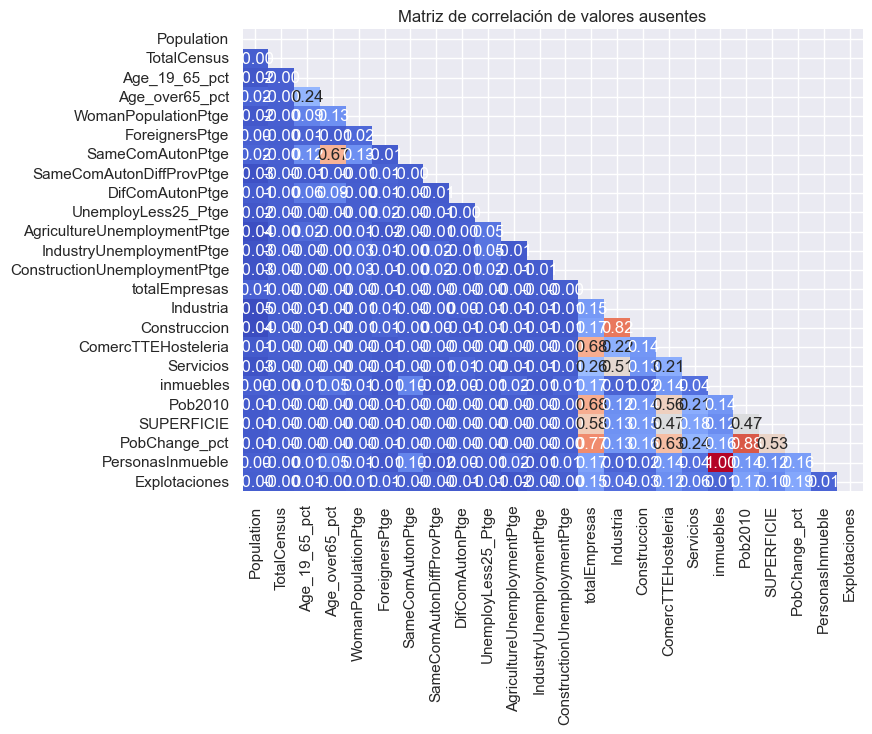

In [118]:
# Patrón de missings
patron_perdidos(datos_input)

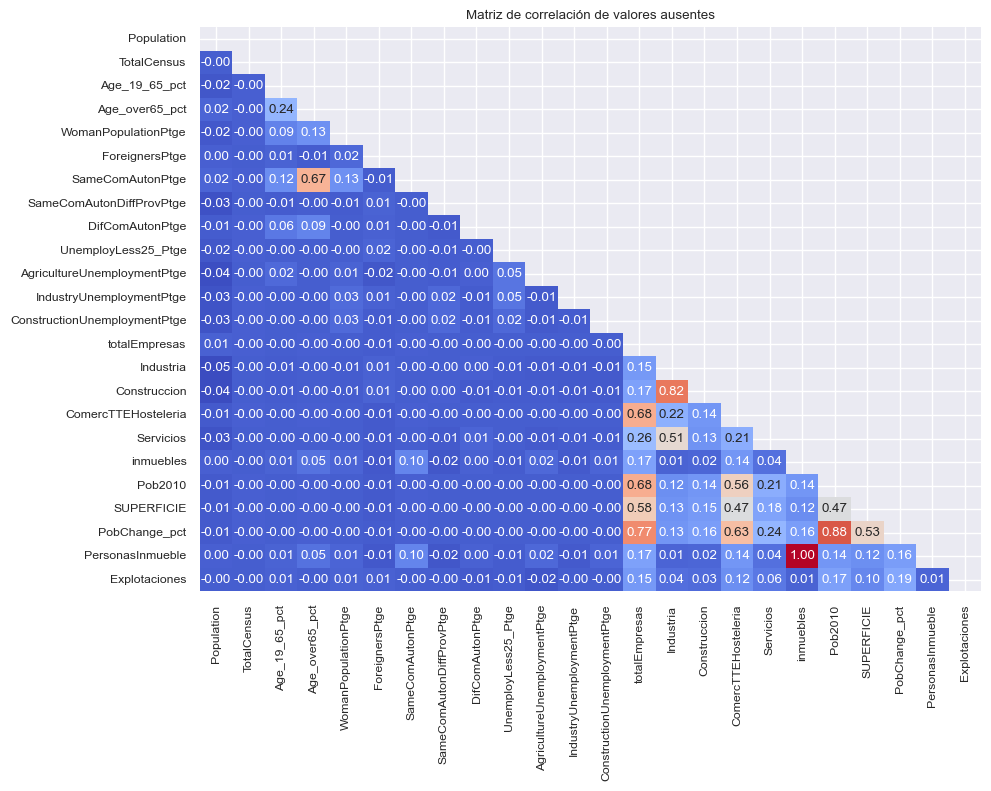

In [119]:
# Versión ajustada de patron_perdidos para mayor número de variables y mejora de visibilidad
correlation_matrix = datos_input[datos_input.columns[datos_input.isna().sum() > 0]].isna().corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=False, mask=mask)
plt.title("Matriz de correlación de valores ausentes")
plt.tight_layout()
plt.show()

In [120]:
# Proporción de missings por variable (guardo la información)
prop_missingsVars = datos_input.isna().sum() / len(datos_input)
prop_missingsVars.sort_values(ascending=False).head(15)

Population                      0.099051
ForeignersPtge                  0.080448
Explotaciones                   0.023284
Industria                       0.023284
SameComAutonDiffProvPtge        0.020328
AgricultureUnemploymentPtge     0.019958
inmuebles                       0.017125
Construccion                    0.017125
PersonasInmueble                0.017001
Servicios                       0.007638
ConstructionUnemploymentPtge    0.006530
IndustryUnemploymentPtge        0.005914
DifComAutonPtge                 0.004928
UnemployLess25_Ptge             0.003203
Age_19_65_pct                   0.002957
dtype: float64

In [121]:
# Variable prop_missings por observación
datos_input['prop_missings'] = datos_input.isna().mean(axis=1)
datos_input['prop_missings'].describe()

count    8117.000000
mean        0.010819
std         0.020497
min         0.000000
25%         0.000000
50%         0.000000
75%         0.030303
max         0.333333
Name: prop_missings, dtype: float64

In [122]:
print('Valores distintos de prop_missings:', len(datos_input['prop_missings'].unique()))

Valores distintos de prop_missings: 8


In [123]:
# Elimino observaciones con más del 50 % de missings
eliminar = datos_input['prop_missings'] > 0.5
print('Observaciones eliminadas:', int(eliminar.sum()))

datos_input = datos_input[~eliminar]
varObjBin   = varObjBin[~eliminar]
varObjCont  = varObjCont[~eliminar]

Observaciones eliminadas: 0


In [124]:
print(datos_input['prop_missings'].describe())
print("Valores distintos:", len(datos_input['prop_missings'].unique()))
print("Valores > 0.10:", (datos_input['prop_missings'] > 0.10).sum())

count    8117.000000
mean        0.010819
std         0.020497
min         0.000000
25%         0.000000
50%         0.000000
75%         0.030303
max         0.333333
Name: prop_missings, dtype: float64
Valores distintos: 8
Valores > 0.10: 10


In [125]:
# Transformo prop_missings en categórica binaria:
# el 99% de municipios tiene prop_missings <= 0.06, con solo 10 obs por encima de 0.10
# → intervalos finos generarían categorías ausentes en test
# Se usan dos categorías: sin ningún missing vs con algún missing
datos_input['prop_missings'] = np.where(datos_input['prop_missings'] == 0, '0', 'con_missings')

variables_input.append('prop_missings')
categoricas_input.append('prop_missings')

In [126]:
# Elimino variables con más del 50 % de missings
eliminar_vars = [prop_missingsVars.index[x] for x in range(len(prop_missingsVars))
                 if prop_missingsVars[x] > 0.5]
print('Variables eliminadas:', eliminar_vars)

datos_input = datos_input.drop(eliminar_vars, axis=1)
numericas_input   = [v for v in numericas_input   if v not in eliminar_vars]
categoricas_input = [v for v in categoricas_input if v not in eliminar_vars]

Variables eliminadas: []


In [127]:
# Imputación aleatoria variables numéricas
for x in numericas_input:
    datos_input[x] = ImputacionCuant(datos_input[x], 'aleatorio')

# Imputación aleatoria variables categóricas
for x in categoricas_input:
    datos_input[x] = ImputacionCuali(datos_input[x], 'aleatorio')

# Verifico que no quedan missings
datos_input.isna().sum().sum()

0

In [128]:
# Guardo datos depurados
datosEleccionesDep = pd.concat([varObjCont, varObjBin, datos_input], axis=1)

with open('datosEleccionesDep.pickle', 'wb') as archivo:
    pickle.dump(datosEleccionesDep, archivo)

## 7. Regresión lineal sobre `AbstentionPtge`

Se aplican los métodos de selección clásica de variables (forward, backward y stepwise) con criterios AIC y BIC sobre las variables originales, sin transformaciones ni interacciones, tal como indica el enunciado.

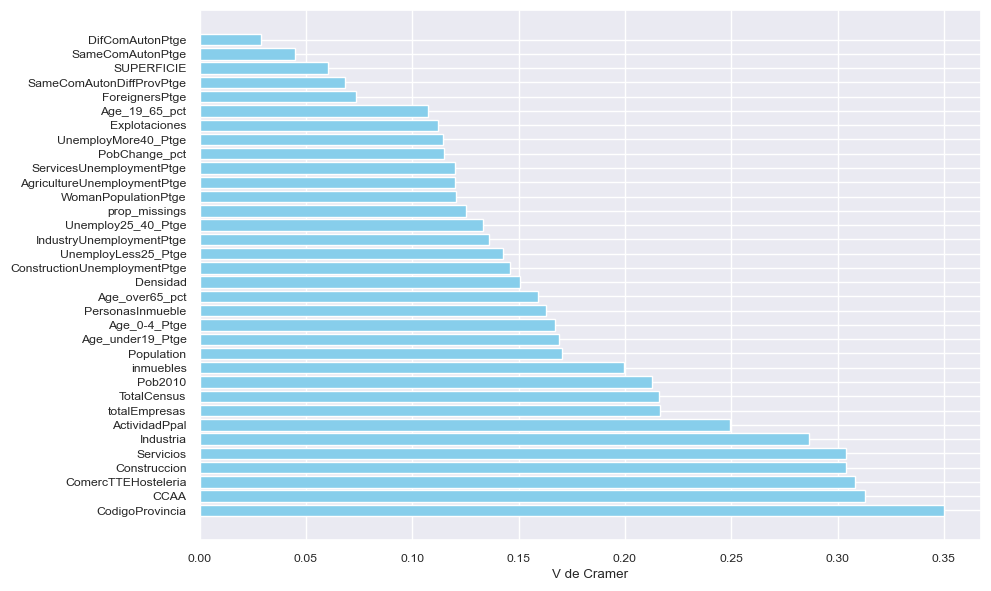

In [129]:
# Cambio función Vcramer para ajuste de medidas
salidaVcramer = {x: Vcramer(datos_input[x], varObjCont) for x in datos_input.columns}
sorted_data = dict(sorted(salidaVcramer.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 6))
plt.barh(list(sorted_data.keys()), list(sorted_data.values()), color='skyblue')
plt.xlabel('V de Cramer')
plt.tight_layout()
plt.show()

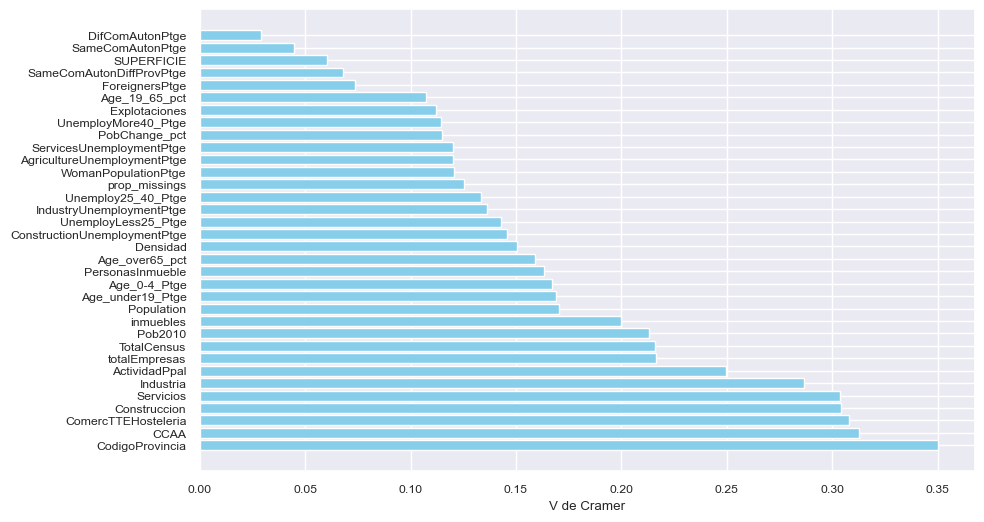

In [130]:
# Importancia de las variables respecto a la objetivo continua
graficoVcramer(datos_input, varObjCont)

In [ ]:
# Partición train / test (80/20)
x_train, x_test, y_train, y_test = train_test_split(
    datos_input, varObjCont, test_size=0.2, random_state=1234567)

print('Train:', x_train.shape, '| Test:', x_test.shape)

var_cont  = numericas_input.copy()
var_categ = categoricas_input.copy()

Train: (6493, 34) | Test: (1624, 34)


In [132]:
# Selección de variables – Forward AIC
modeloForwAIC = lm_forward(y_train, x_train, var_cont, var_categ, [], 'AIC')
Rsq(modeloForwAIC['Modelo'], y_train, modeloForwAIC['X'])
x_test_ForwAIC = crear_data_modelo(x_test, modeloForwAIC['Variables']['cont'],
                                           modeloForwAIC['Variables']['categ'],
                                           modeloForwAIC['Variables']['inter'])
Rsq(modeloForwAIC['Modelo'], y_test, x_test_ForwAIC)
len(modeloForwAIC['Modelo'].params)

Start: AIC = 44573.50641861909

y ~ 1

                       Variable          AIC
              + CodigoProvincia 41684.532709
                         + CCAA 42165.778194
             + Age_under19_Ptge 43827.294288
                + ActividadPpal 43886.309575
             + PersonasInmueble 43892.126676
                 + Age_0-4_Ptge 43893.573213
               + Age_over65_pct 44023.694364
                     + Densidad 44186.835888
                   + Population 44208.199046
          + WomanPopulationPtge 44315.523470
                + Age_19_65_pct 44384.573842
                + PobChange_pct 44431.409934
     + IndustryUnemploymentPtge 44469.574716
          + UnemployMore40_Ptge 44472.591451
           + Unemploy25_40_Ptge 44472.620736
     + ServicesUnemploymentPtge 44476.080848
               + ForeignersPtge 44478.749641
                + Explotaciones 44485.028365
                + prop_missings 44504.782226
     + SameComAutonDiffProvPtge 44507.336676
             + S

72

In [133]:
# Selección de variables – Forward BIC
modeloForwBIC = lm_forward(y_train, x_train, var_cont, var_categ, [], 'BIC')
Rsq(modeloForwBIC['Modelo'], y_train, modeloForwBIC['X'])
x_test_ForwBIC = crear_data_modelo(x_test, modeloForwBIC['Variables']['cont'],
                                           modeloForwBIC['Variables']['categ'],
                                           modeloForwBIC['Variables']['inter'])
Rsq(modeloForwBIC['Modelo'], y_test, x_test_ForwBIC)
len(modeloForwBIC['Modelo'].params)

Start: BIC = 44580.2848985716

y ~ 1

                       Variable          BIC
              + CodigoProvincia 42023.456707
                         + CCAA 42281.012353
             + Age_under19_Ptge 43840.851248
             + PersonasInmueble 43905.683636
                + ActividadPpal 43906.645015
                 + Age_0-4_Ptge 43907.130172
               + Age_over65_pct 44037.251324
                     + Densidad 44213.949807
                   + Population 44221.756006
          + WomanPopulationPtge 44329.080430
                + Age_19_65_pct 44398.130802
                + PobChange_pct 44444.966894
     + IndustryUnemploymentPtge 44483.131676
          + UnemployMore40_Ptge 44486.148411
           + Unemploy25_40_Ptge 44486.177696
     + ServicesUnemploymentPtge 44489.637808
               + ForeignersPtge 44492.306601
                + Explotaciones 44498.585325
                + prop_missings 44518.339186
     + SameComAutonDiffProvPtge 44520.893636
             + Sa

62

In [134]:
# Selección de variables – Backward AIC
modeloBackAIC = lm_backward(y_train, x_train, var_cont, var_categ, [], 'AIC')
Rsq(modeloBackAIC['Modelo'], y_train, modeloBackAIC['X'])
x_test_BackAIC = crear_data_modelo(x_test, modeloBackAIC['Variables']['cont'],
                                           modeloBackAIC['Variables']['categ'],
                                           modeloBackAIC['Variables']['inter'])
Rsq(modeloBackAIC['Modelo'], y_test, x_test_BackAIC)
len(modeloBackAIC['Modelo'].params)

Start: AIC = 41048.87961321644

y ~ Population + TotalCensus + Age_0-4_Ptge + Age_under19_Ptge + Age_19_65_pct + Age_over65_pct + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + DifComAutonPtge + UnemployLess25_Ptge + Unemploy25_40_Ptge + UnemployMore40_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + totalEmpresas + Industria + Construccion + ComercTTEHosteleria + Servicios + inmuebles + Pob2010 + SUPERFICIE + PobChange_pct + PersonasInmueble + Explotaciones + CodigoProvincia + CCAA + ActividadPpal + Densidad + prop_missings

                       Variable          AIC
              - CodigoProvincia 41549.686391
                - ActividadPpal 41092.077959
             - SameComAutonPtge 41083.090167
     - ServicesUnemploymentPtge 41080.790505
 - ConstructionUnemploymentPtge 41078.325506
     - IndustryUnemploymentPtge 41071.705341
                  - TotalCensus 41064.8775

74

In [135]:
# Selección de variables – Backward BIC
modeloBackBIC = lm_backward(y_train, x_train, var_cont, var_categ, [], 'BIC')
Rsq(modeloBackBIC['Modelo'], y_train, modeloBackBIC['X'])
x_test_BackBIC = crear_data_modelo(x_test, modeloBackBIC['Variables']['cont'],
                                           modeloBackBIC['Variables']['categ'],
                                           modeloBackBIC['Variables']['inter'])
Rsq(modeloBackBIC['Modelo'], y_test, x_test_BackBIC)
len(modeloBackBIC['Modelo'].params)

Start: BIC = 41625.05040917966

y ~ Population + TotalCensus + Age_0-4_Ptge + Age_under19_Ptge + Age_19_65_pct + Age_over65_pct + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + DifComAutonPtge + UnemployLess25_Ptge + Unemploy25_40_Ptge + UnemployMore40_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + totalEmpresas + Industria + Construccion + ComercTTEHosteleria + Servicios + inmuebles + Pob2010 + SUPERFICIE + PobChange_pct + PersonasInmueble + Explotaciones + CodigoProvincia + CCAA + ActividadPpal + Densidad + prop_missings

                       Variable          BIC
              - CodigoProvincia 41902.167349
                - ActividadPpal 41654.691795
             - SameComAutonPtge 41652.482483
     - ServicesUnemploymentPtge 41650.182821
 - ConstructionUnemploymentPtge 41647.717822
     - IndustryUnemploymentPtge 41641.097657
                  - TotalCensus 41634.2698

67

In [136]:
# Selección de variables – Stepwise AIC
modeloStepAIC = lm_stepwise(y_train, x_train, var_cont, var_categ, [], 'AIC')
Rsq(modeloStepAIC['Modelo'], y_train, modeloStepAIC['X'])
x_test_StepAIC = crear_data_modelo(x_test, modeloStepAIC['Variables']['cont'],
                                           modeloStepAIC['Variables']['categ'],
                                           modeloStepAIC['Variables']['inter'])
Rsq(modeloStepAIC['Modelo'], y_test, x_test_StepAIC)
len(modeloStepAIC['Modelo'].params)

Start: AIC = 44573.50641861909

y ~ 1

                       Variable          AIC
              + CodigoProvincia 41684.532709
                         + CCAA 42165.778194
             + Age_under19_Ptge 43827.294288
                + ActividadPpal 43886.309575
             + PersonasInmueble 43892.126676
                 + Age_0-4_Ptge 43893.573213
               + Age_over65_pct 44023.694364
                     + Densidad 44186.835888
                   + Population 44208.199046
          + WomanPopulationPtge 44315.523470
                + Age_19_65_pct 44384.573842
                + PobChange_pct 44431.409934
     + IndustryUnemploymentPtge 44469.574716
          + UnemployMore40_Ptge 44472.591451
           + Unemploy25_40_Ptge 44472.620736
     + ServicesUnemploymentPtge 44476.080848
               + ForeignersPtge 44478.749641
                + Explotaciones 44485.028365
                + prop_missings 44504.782226
     + SameComAutonDiffProvPtge 44507.336676
             + S

71

In [137]:
# Selección de variables – Stepwise BIC
modeloStepBIC = lm_stepwise(y_train, x_train, var_cont, var_categ, [], 'BIC')
Rsq(modeloStepBIC['Modelo'], y_train, modeloStepBIC['X'])
x_test_StepBIC = crear_data_modelo(x_test, modeloStepBIC['Variables']['cont'],
                                           modeloStepBIC['Variables']['categ'],
                                           modeloStepBIC['Variables']['inter'])
Rsq(modeloStepBIC['Modelo'], y_test, x_test_StepBIC)
len(modeloStepBIC['Modelo'].params)

Start: BIC = 44580.2848985716

y ~ 1

                       Variable          BIC
              + CodigoProvincia 42023.456707
                         + CCAA 42281.012353
             + Age_under19_Ptge 43840.851248
             + PersonasInmueble 43905.683636
                + ActividadPpal 43906.645015
                 + Age_0-4_Ptge 43907.130172
               + Age_over65_pct 44037.251324
                     + Densidad 44213.949807
                   + Population 44221.756006
          + WomanPopulationPtge 44329.080430
                + Age_19_65_pct 44398.130802
                + PobChange_pct 44444.966894
     + IndustryUnemploymentPtge 44483.131676
          + UnemployMore40_Ptge 44486.148411
           + Unemploy25_40_Ptge 44486.177696
     + ServicesUnemploymentPtge 44489.637808
               + ForeignersPtge 44492.306601
                + Explotaciones 44498.585325
                + prop_missings 44518.339186
     + SameComAutonDiffProvPtge 44520.893636
             + Sa

62

In [138]:
#Resultados
modelos_lm = {
    'ForwAIC': (modeloForwAIC, x_test_ForwAIC),
    'ForwBIC': (modeloForwBIC, x_test_ForwBIC),
    'BackAIC': (modeloBackAIC, x_test_BackAIC),
    'BackBIC': (modeloBackBIC, x_test_BackBIC),
    'StepAIC': (modeloStepAIC, x_test_StepAIC),
    'StepBIC': (modeloStepBIC, x_test_StepBIC),
}

for nombre, (modelo, x_te) in modelos_lm.items():
    r2_train = Rsq(modelo['Modelo'], y_train, modelo['X'])
    r2_test  = Rsq(modelo['Modelo'], y_test, x_te)
    params   = len(modelo['Modelo'].params)
    print(f"{nombre}: R²Train={r2_train:.4f}, R²Test={r2_test:.4f}, Params={params}")

ForwAIC: R²Train=0.4304, R²Test=0.4185, Params=72
ForwBIC: R²Train=0.4254, R²Test=0.4156, Params=62
BackAIC: R²Train=0.4331, R²Test=0.4211, Params=74
BackBIC: R²Train=0.4302, R²Test=0.4207, Params=67
StepAIC: R²Train=0.4302, R²Test=0.4176, Params=71
StepBIC: R²Train=0.4254, R²Test=0.4156, Params=62


### 7.1 Selección del modelo ganador lineal

In [139]:
# Validación cruzada repetida (20 repeticiones × 5 folds)
results_lm = pd.DataFrame({'Rsquared': [], 'Resample': [], 'Modelo': []})

for rep in range(20):
    modelo1VC = validacion_cruzada_lm(5, x_train, y_train,
                    modeloForwAIC['Variables']['cont'], modeloForwAIC['Variables']['categ'])
    modelo2VC = validacion_cruzada_lm(5, x_train, y_train,
                    modeloForwBIC['Variables']['cont'], modeloForwBIC['Variables']['categ'])
    modelo3VC = validacion_cruzada_lm(5, x_train, y_train,
                    modeloBackAIC['Variables']['cont'], modeloBackAIC['Variables']['categ'])
    modelo4VC = validacion_cruzada_lm(5, x_train, y_train,
                    modeloBackBIC['Variables']['cont'], modeloBackBIC['Variables']['categ'])
    modelo5VC = validacion_cruzada_lm(5, x_train, y_train,
                    modeloStepAIC['Variables']['cont'], modeloStepAIC['Variables']['categ'])
    modelo6VC = validacion_cruzada_lm(5, x_train, y_train,
                    modeloStepBIC['Variables']['cont'], modeloStepBIC['Variables']['categ'])

    results_rep = pd.DataFrame({
        'Rsquared': modelo1VC + modelo2VC + modelo3VC + modelo4VC + modelo5VC + modelo6VC,
        'Resample': ['Rep' + str(rep + 1)] * 5 * 6,
        'Modelo':   [1]*5 + [2]*5 + [3]*5 + [4]*5 + [5]*5 + [6]*5
    })
    results_lm = pd.concat([results_lm, results_rep], axis=0)

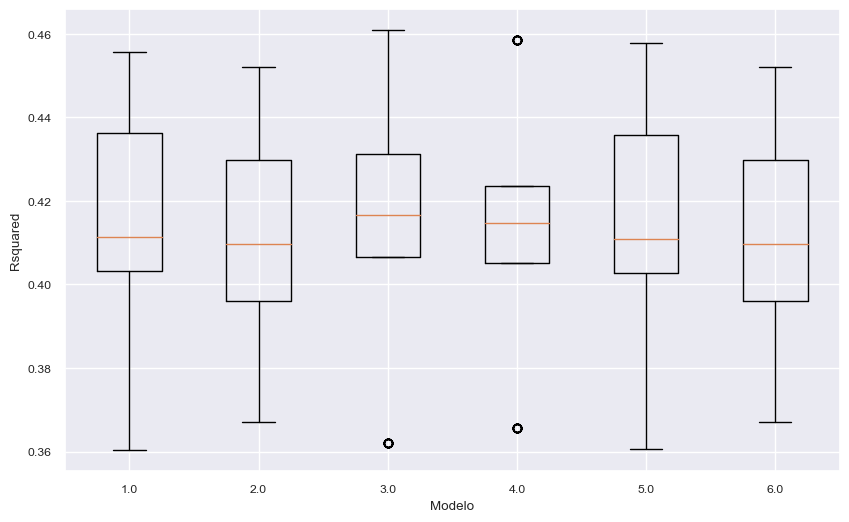

Modelo
1.0    0.413337
2.0    0.410930
3.0    0.415445
4.0    0.413475
5.0    0.413584
6.0    0.410930
Name: Rsquared, dtype: float64
Modelo
1.0    0.032509
2.0    0.029182
3.0    0.032583
4.0    0.030124
5.0    0.032969
6.0    0.029182
Name: Rsquared, dtype: float64
[72, 62, 74, 67, 71, 62]


In [140]:
# Boxplot validación cruzada
# Modelos: 1=ForwAIC, 2=ForwBIC, 3=BackAIC, 4=BackBIC, 5=StepAIC, 6=StepBIC
plt.figure(figsize=(10, 6))
plt.grid(True)
grupo_metrica = results_lm.groupby('Modelo')['Rsquared']
boxplot_data  = [grupo_metrica.get_group(g).tolist() for g in grupo_metrica.groups]
plt.boxplot(boxplot_data, labels=grupo_metrica.groups.keys())
plt.xlabel('Modelo')
plt.ylabel('Rsquared')
plt.show()

media_r2 = results_lm.groupby('Modelo')['Rsquared'].mean()
std_r2   = results_lm.groupby('Modelo')['Rsquared'].std()
print(media_r2)
print(std_r2)

num_params = [len(modeloForwAIC['Modelo'].params), len(modeloForwBIC['Modelo'].params),
              len(modeloBackAIC['Modelo'].params), len(modeloBackBIC['Modelo'].params),
              len(modeloStepAIC['Modelo'].params), len(modeloStepBIC['Modelo'].params)]
print(num_params)

In [ ]:
# Modelo ganador lineal
ModeloGanadorLM = modeloStepBIC

ModeloGanadorLM['Modelo'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         AbstentionPtge   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     78.06
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        00:20:40   Log-Likelihood:                -20487.
No. Observations:                6493   AIC:                         4.110e+04
Df Residuals:                    6431   BIC:                         4.152e+04
Df Model:                          61                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           42.2990      1.772     23.871      0.000      38.825      45.773
SameComAutonPtge                -0.0961      0.008    -12.330      0.000      -0.111      -0.081
Explotaciones                    0.0024      0.000      6.165      0.000       0.002       0.003
ConstructionUnemploymentPtge     0.0378      0.007      5.496      0.000       0.024       0.051
ServicesUnemploymentPtge         0.0190      0.003      5.691      0.000       0.012       0.026
IndustryUnemploymentPtge         0.0344      0.007      4.595      0.000       0.020       0.049
Age_19_65_pct                   -0.0602      0.013     -4.527      0.000      -0.086      -0.034
Age_0-4_Ptge                     0.1927      0.051      3.802      0.000       0.093       0.292
AgricultureUnemploymentPtge      0.0308      0.009      3.487      0.000       0.013       0.048
WomanPopulationPtge             -0.0681      0.021     -3.200      0.001      -0.110      -0.026
SUPERFICIE                     2.71e-05   8.77e-06      3.089      0.002     9.9e-06    4.43e-05
CodigoProvincia_10              -2.9958      0.969     -3.091      0.002      -4.896      -1.096
CodigoProvincia_11               4.2698      1.364      3.130      0.002       1.596       6.944
CodigoProvincia_12              -8.9245      1.015     -8.788      0.000     -10.915      -6.934
CodigoProvincia_13              -5.4919      1.084     -5.066      0.000      -7.617      -3.367
CodigoProvincia_14              -4.2946      1.164     -3.689      0.000      -6.577      -2.012
CodigoProvincia_15               1.7894      1.114      1.607      0.108      -0.394       3.972
CodigoProvincia_16              -7.3437      0.960     -7.649      0.000      -9.226      -5.462
CodigoProvincia_17               4.3195      0.954      4.526      0.000       2.448       6.191
CodigoProvincia_18              -0.9268      1.003     -0.924      0.355      -2.893       1.039
CodigoProvincia_19              -8.9849      0.951     -9.451      0.000     -10.849      -7.121
CodigoProvincia_2               -6.9614      1.102     -6.319      0.000      -9.121      -4.802
CodigoProvincia_20               6.3371      1.086      5.834      0.000       4.208       8.466
CodigoProvincia_21               3.2042      1.125      2.849      0.004       0.999       5.409
CodigoProvincia_22              -2.9141      0.968     -3.010      0.003      -4.812      -1.016
CodigoProvincia_23              -6.4881      1.112     -5.834      0.000      -8.668      -4.308
CodigoProvincia_24              -0.5105      0.973     -0.525      0.600      -2.418       1.397
CodigoProvincia_25               7.2084      0.954      7.560      0.000       5.339       9.078
CodigoProvincia_26             -10.0048      0.985    -10.152      0.000    

In [142]:
# Estabilidad train/test del modelo ganador
Rsq(ModeloGanadorLM['Modelo'], y_train, ModeloGanadorLM['X'])

x_test_ganador_lm = crear_data_modelo(x_test, ModeloGanadorLM['Variables']['cont'],
                                              ModeloGanadorLM['Variables']['categ'],
                                              ModeloGanadorLM['Variables']['inter'])
Rsq(ModeloGanadorLM['Modelo'], y_test, x_test_ganador_lm)

0.41562329309529034

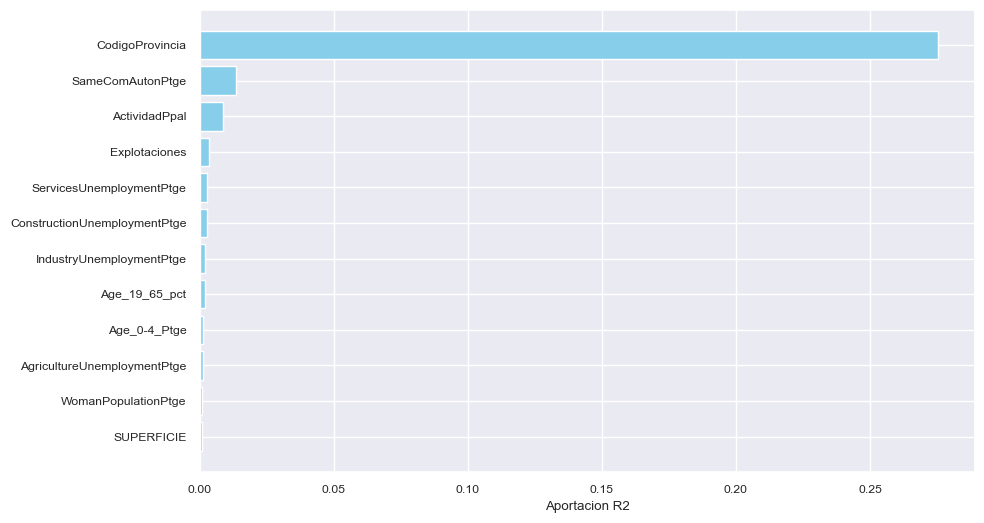

,Variables,R2
9,SUPERFICIE,0.000853
8,WomanPopulationPtge,0.000915
7,AgricultureUnemploymentPtge,0.001086
6,Age_0-4_Ptge,0.001292
5,Age_19_65_pct,0.001831
4,IndustryUnemploymentPtge,0.001886
2,ConstructionUnemploymentPtge,0.002699
3,ServicesUnemploymentPtge,0.002894
1,Explotaciones,0.003396
11,ActividadPpal,0.008659


In [143]:
# Importancia de variables del modelo ganador
modelEffectSizes(ModeloGanadorLM, y_train, x_train,
                 ModeloGanadorLM['Variables']['cont'],
                 ModeloGanadorLM['Variables']['categ'],
                 ModeloGanadorLM['Variables']['inter'])

### 7.2 Interpretación de coeficientes

**TODO:** interpretar dos coeficientes del summary (una variable continua y una categórica) con los valores reales obtenidos.

## 8. Regresión logística sobre `AbstencionAlta`

El procedimiento es análogo al de regresión lineal (apartado 7). La métrica de ajuste cambia a pseudo-R² y AUC. Se aplican los mismos métodos de selección clásica sin transformaciones ni interacciones.

In [ ]:
# Reparto de la variable binaria
pd.DataFrame({
    'n': varObjBin.value_counts(),
    '%': varObjBin.value_counts(normalize=True)})

,n,%
0,5591,0.688801
1,2526,0.311199


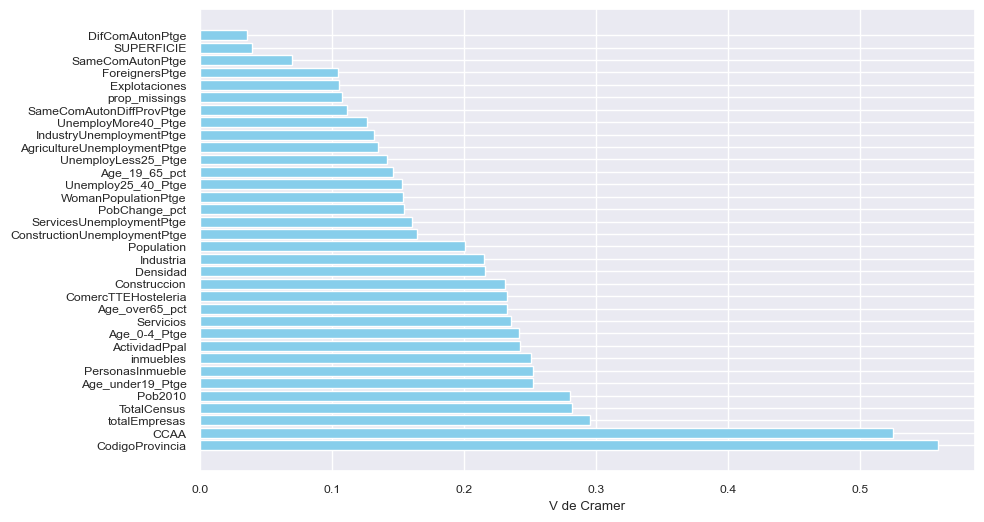

In [145]:
# Importancia de las variables respecto a la objetivo binaria
graficoVcramer(datos_input, varObjBin)

In [ ]:
# Partición train / test estratificada
x_train_glm, x_test_glm, y_train_glm, y_test_glm = train_test_split(
    datos_input, varObjBin, test_size=0.2, random_state=1234567, stratify=varObjBin)

y_train_glm = y_train_glm.astype(int)
y_test_glm  = y_test_glm.astype(int)

print('Train:', x_train_glm.shape, '| Test:', x_test_glm.shape)

Train: (6493, 34) | Test: (1624, 34)


In [147]:
# Selección de variables – Forward AIC
modeloLog_ForwAIC = glm_forward(y_train_glm, x_train_glm, var_cont, var_categ, [], 'AIC')
pseudoR2(modeloLog_ForwAIC['Modelo'], modeloLog_ForwAIC['X'], y_train_glm)
x_test_log_ForwAIC = crear_data_modelo(x_test_glm, modeloLog_ForwAIC['Variables']['cont'],
                                                    modeloLog_ForwAIC['Variables']['categ'],
                                                    modeloLog_ForwAIC['Variables']['inter'])
pseudoR2(modeloLog_ForwAIC['Modelo'], x_test_log_ForwAIC, y_test_glm)
len(modeloLog_ForwAIC['Modelo'].coef_[0])

Start: AIC = 8056.667605348029

y ~ 1

                       Variable         AIC
              + CodigoProvincia 5966.154107
                         + CCAA 6236.747504
             + PersonasInmueble 7672.454556
             + Age_under19_Ptge 7689.699159
                + ActividadPpal 7692.732703
                 + Age_0-4_Ptge 7732.125102
                     + Densidad 7762.331790
               + Age_over65_pct 7784.673157
                   + Population 7880.421795
          + WomanPopulationPtge 7952.520018
     + SameComAutonDiffProvPtge 7960.137023
                + Age_19_65_pct 7969.863710
                + prop_missings 7978.215398
     + IndustryUnemploymentPtge 7998.176247
                + PobChange_pct 8007.190446
                + Explotaciones 8008.704119
               + ForeignersPtge 8014.402797
             + SameComAutonPtge 8025.534457
           + Unemploy25_40_Ptge 8025.613100
                 + Construccion 8025.937439
                    + Industria 8026.

79

In [148]:
# Selección de variables – Forward BIC
modeloLog_ForwBIC = glm_forward(y_train_glm, x_train_glm, var_cont, var_categ, [], 'BIC')
pseudoR2(modeloLog_ForwBIC['Modelo'], modeloLog_ForwBIC['X'], y_train_glm)
x_test_log_ForwBIC = crear_data_modelo(x_test_glm, modeloLog_ForwBIC['Variables']['cont'],
                                                    modeloLog_ForwBIC['Variables']['categ'],
                                                    modeloLog_ForwBIC['Variables']['inter'])
pseudoR2(modeloLog_ForwBIC['Modelo'], x_test_log_ForwBIC, y_test_glm)
len(modeloLog_ForwBIC['Modelo'].coef_[0])

Start: BIC = 8070.2245652530455

y ~ 1

                       Variable         BIC
              + CodigoProvincia 5979.711067
                         + CCAA 6250.304464
             + PersonasInmueble 7686.011516
             + Age_under19_Ptge 7703.256119
                + ActividadPpal 7706.289663
                 + Age_0-4_Ptge 7745.682062
                     + Densidad 7775.888750
               + Age_over65_pct 7798.230117
                   + Population 7893.978755
          + WomanPopulationPtge 7966.076978
     + SameComAutonDiffProvPtge 7973.693983
                + Age_19_65_pct 7983.420670
                + prop_missings 7991.772358
     + IndustryUnemploymentPtge 8011.733207
                + PobChange_pct 8020.747406
                + Explotaciones 8022.261079
               + ForeignersPtge 8027.959757
             + SameComAutonPtge 8039.091417
           + Unemploy25_40_Ptge 8039.170060
                 + Construccion 8039.494399
                    + Industria 8040

79

In [149]:
# Selección de variables – Backward AIC
modeloLog_BackAIC = glm_backward(y_train_glm, x_train_glm, var_cont, var_categ, [], 'AIC')
pseudoR2(modeloLog_BackAIC['Modelo'], modeloLog_BackAIC['X'], y_train_glm)
x_test_log_BackAIC = crear_data_modelo(x_test_glm, modeloLog_BackAIC['Variables']['cont'],
                                                    modeloLog_BackAIC['Variables']['categ'],
                                                    modeloLog_BackAIC['Variables']['inter'])
pseudoR2(modeloLog_BackAIC['Modelo'], x_test_log_BackAIC, y_test_glm)
len(modeloLog_BackAIC['Modelo'].coef_[0])

Start: AIC = 5564.626430968825

y ~ Population + TotalCensus + Age_0-4_Ptge + Age_under19_Ptge + Age_19_65_pct + Age_over65_pct + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + DifComAutonPtge + UnemployLess25_Ptge + Unemploy25_40_Ptge + UnemployMore40_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + totalEmpresas + Industria + Construccion + ComercTTEHosteleria + Servicios + inmuebles + Pob2010 + SUPERFICIE + PobChange_pct + PersonasInmueble + Explotaciones + CodigoProvincia + CCAA + ActividadPpal + Densidad + prop_missings

                       Variable         AIC
              - CodigoProvincia 5852.989181
                         - CCAA 5590.555735
             - SameComAutonPtge 5587.556961
          - ComercTTEHosteleria 5585.233419
                - totalEmpresas 5584.063171
          - WomanPopulationPtge 5580.341867
                - ActividadPpal 5579.355459
     

76

In [150]:
# Selección de variables – Backward BIC
modeloLog_BackBIC = glm_backward(y_train_glm, x_train_glm, var_cont, var_categ, [], 'BIC')
pseudoR2(modeloLog_BackBIC['Modelo'], modeloLog_BackBIC['X'], y_train_glm)
x_test_log_BackBIC = crear_data_modelo(x_test_glm, modeloLog_BackBIC['Variables']['cont'],
                                                    modeloLog_BackBIC['Variables']['categ'],
                                                    modeloLog_BackBIC['Variables']['inter'])
pseudoR2(modeloLog_BackBIC['Modelo'], x_test_log_BackBIC, y_test_glm)
len(modeloLog_BackBIC['Modelo'].coef_[0])

Start: BIC = 5578.183390873842

y ~ Population + TotalCensus + Age_0-4_Ptge + Age_under19_Ptge + Age_19_65_pct + Age_over65_pct + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + DifComAutonPtge + UnemployLess25_Ptge + Unemploy25_40_Ptge + UnemployMore40_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + totalEmpresas + Industria + Construccion + ComercTTEHosteleria + Servicios + inmuebles + Pob2010 + SUPERFICIE + PobChange_pct + PersonasInmueble + Explotaciones + CodigoProvincia + CCAA + ActividadPpal + Densidad + prop_missings

                       Variable         BIC
              - CodigoProvincia 5866.546141
                         - CCAA 5604.112695
             - SameComAutonPtge 5601.113921
          - ComercTTEHosteleria 5598.790379
                - totalEmpresas 5597.620131
          - WomanPopulationPtge 5593.898827
                - ActividadPpal 5592.912419
     

76

In [151]:
# Selección de variables – Stepwise AIC
modeloLog_StepAIC = glm_stepwise(y_train_glm, x_train_glm, var_cont, var_categ, [], 'AIC')
pseudoR2(modeloLog_StepAIC['Modelo'], modeloLog_StepAIC['X'], y_train_glm)
x_test_log_StepAIC = crear_data_modelo(x_test_glm, modeloLog_StepAIC['Variables']['cont'],
                                                    modeloLog_StepAIC['Variables']['categ'],
                                                    modeloLog_StepAIC['Variables']['inter'])
pseudoR2(modeloLog_StepAIC['Modelo'], x_test_log_StepAIC, y_test_glm)
len(modeloLog_StepAIC['Modelo'].coef_[0])

Start: AIC = 8056.667605348029

y ~ 1

                       Variable         AIC
              + CodigoProvincia 5966.154107
                         + CCAA 6236.747504
             + PersonasInmueble 7672.454556
             + Age_under19_Ptge 7689.699159
                + ActividadPpal 7692.732703
                 + Age_0-4_Ptge 7732.125102
                     + Densidad 7762.331790
               + Age_over65_pct 7784.673157
                   + Population 7880.421795
          + WomanPopulationPtge 7952.520018
     + SameComAutonDiffProvPtge 7960.137023
                + Age_19_65_pct 7969.863710
                + prop_missings 7978.215398
     + IndustryUnemploymentPtge 7998.176247
                + PobChange_pct 8007.190446
                + Explotaciones 8008.704119
               + ForeignersPtge 8014.402797
             + SameComAutonPtge 8025.534457
           + Unemploy25_40_Ptge 8025.613100
                 + Construccion 8025.937439
                    + Industria 8026.

75

In [152]:
# Selección de variables – Stepwise BIC
modeloLog_StepBIC = glm_stepwise(y_train_glm, x_train_glm, var_cont, var_categ, [], 'BIC')
pseudoR2(modeloLog_StepBIC['Modelo'], modeloLog_StepBIC['X'], y_train_glm)
x_test_log_StepBIC = crear_data_modelo(x_test_glm, modeloLog_StepBIC['Variables']['cont'],
                                                    modeloLog_StepBIC['Variables']['categ'],
                                                    modeloLog_StepBIC['Variables']['inter'])
pseudoR2(modeloLog_StepBIC['Modelo'], x_test_log_StepBIC, y_test_glm)
len(modeloLog_StepBIC['Modelo'].coef_[0])

Start: BIC = 8070.2245652530455

y ~ 1

                       Variable         BIC
              + CodigoProvincia 5979.711067
                         + CCAA 6250.304464
             + PersonasInmueble 7686.011516
             + Age_under19_Ptge 7703.256119
                + ActividadPpal 7706.289663
                 + Age_0-4_Ptge 7745.682062
                     + Densidad 7775.888750
               + Age_over65_pct 7798.230117
                   + Population 7893.978755
          + WomanPopulationPtge 7966.076978
     + SameComAutonDiffProvPtge 7973.693983
                + Age_19_65_pct 7983.420670
                + prop_missings 7991.772358
     + IndustryUnemploymentPtge 8011.733207
                + PobChange_pct 8020.747406
                + Explotaciones 8022.261079
               + ForeignersPtge 8027.959757
             + SameComAutonPtge 8039.091417
           + Unemploy25_40_Ptge 8039.170060
                 + Construccion 8039.494399
                    + Industria 8040

75

### 8.1 Selección del modelo ganador logístico

Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


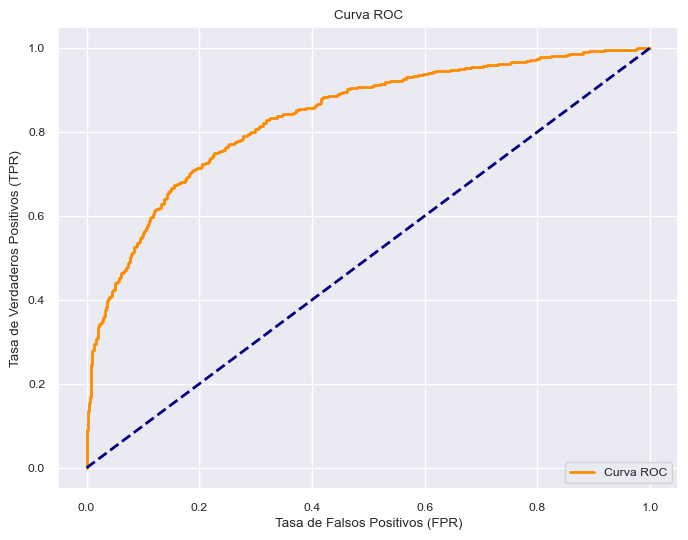

Área bajo la curva ROC = 0.8359178545200363
ForwAIC: pR²Train=0.3013, pR²Test=0.2769, AUC=0.8359, Params=79
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


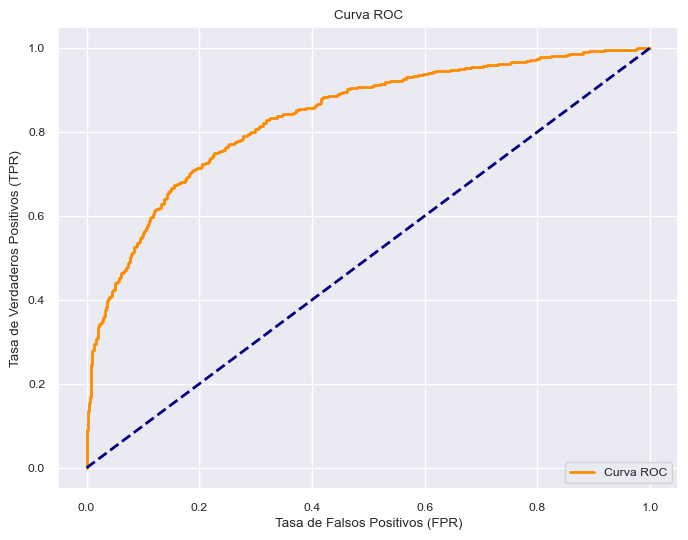

Área bajo la curva ROC = 0.8359178545200363
ForwBIC: pR²Train=0.3013, pR²Test=0.2769, AUC=0.8359, Params=79
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


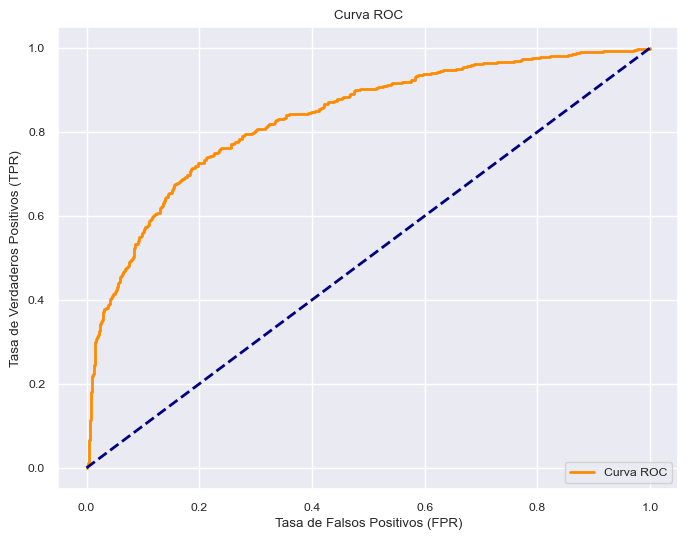

Área bajo la curva ROC = 0.8326104460311983
BackAIC: pR²Train=0.3008, pR²Test=0.2529, AUC=0.8326, Params=76
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


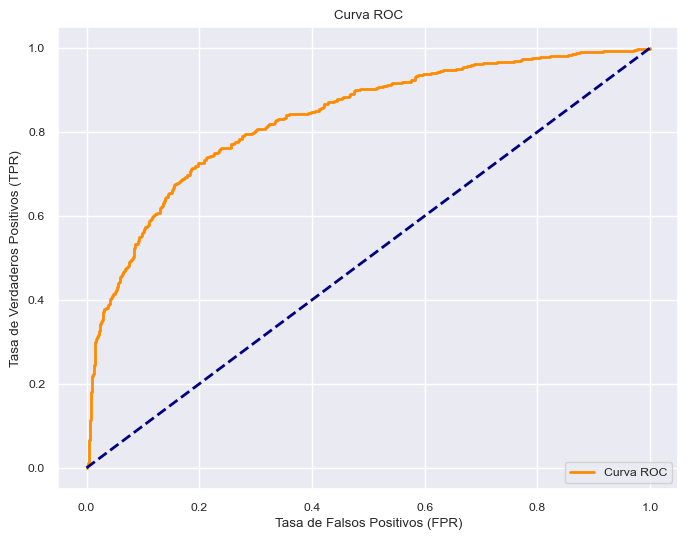

Área bajo la curva ROC = 0.8326104460311983
BackBIC: pR²Train=0.3008, pR²Test=0.2529, AUC=0.8326, Params=76
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


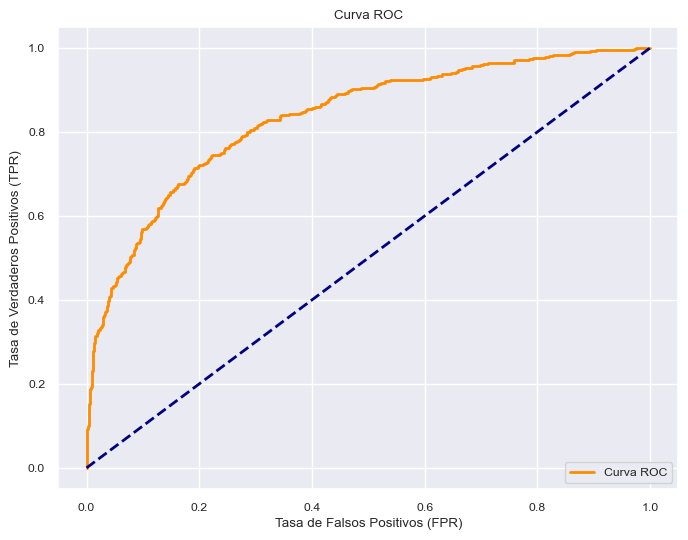

Área bajo la curva ROC = 0.8344172218830462
StepAIC: pR²Train=0.2992, pR²Test=0.2751, AUC=0.8344, Params=75
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


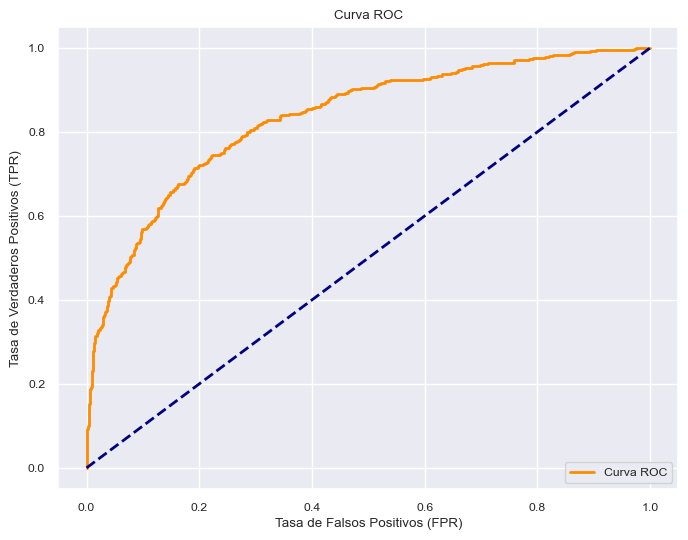

Área bajo la curva ROC = 0.8344172218830462
StepBIC: pR²Train=0.2992, pR²Test=0.2751, AUC=0.8344, Params=75


In [153]:
modelos_glm = {
    'ForwAIC': (modeloLog_ForwAIC, x_test_log_ForwAIC),
    'ForwBIC': (modeloLog_ForwBIC, x_test_log_ForwBIC),
    'BackAIC': (modeloLog_BackAIC, x_test_log_BackAIC),
    'BackBIC': (modeloLog_BackBIC, x_test_log_BackBIC),
    'StepAIC': (modeloLog_StepAIC, x_test_log_StepAIC),
    'StepBIC': (modeloLog_StepBIC, x_test_log_StepBIC),
}

for nombre, (modelo, x_te) in modelos_glm.items():
    pr2_train = pseudoR2(modelo['Modelo'], modelo['X'], y_train_glm)
    pr2_test  = pseudoR2(modelo['Modelo'], x_te, y_test_glm)
    auc       = curva_roc(x_te, y_test_glm, modelo)
    params    = len(modelo['Modelo'].coef_[0])
    print(f"{nombre}: pR²Train={pr2_train:.4f}, pR²Test={pr2_test:.4f}, AUC={auc:.4f}, Params={params}")

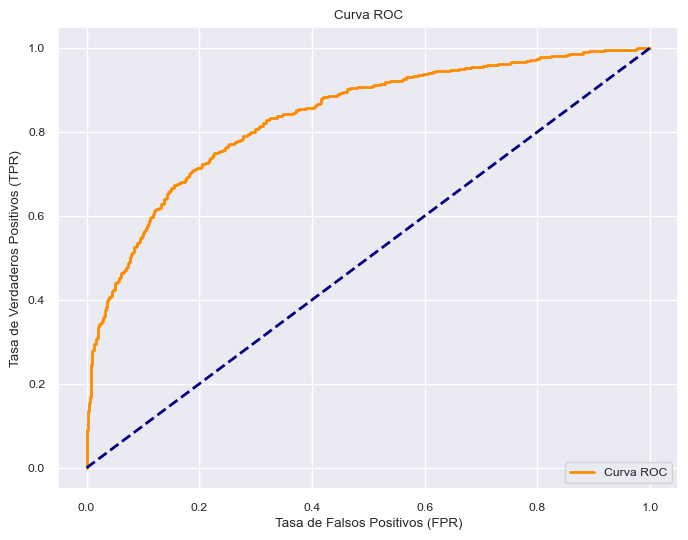

Área bajo la curva ROC = 0.8359178545200363


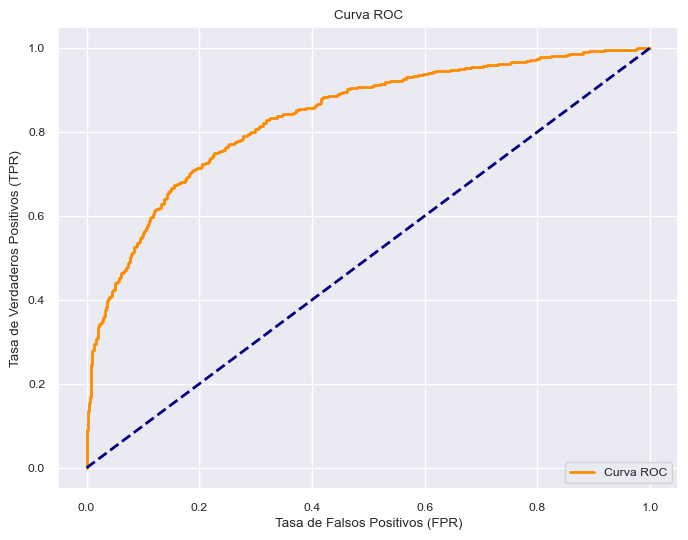

Área bajo la curva ROC = 0.8359178545200363


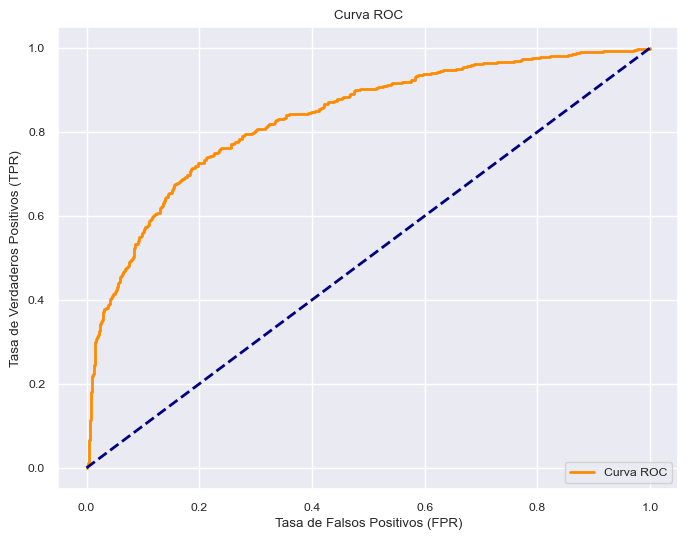

Área bajo la curva ROC = 0.8326104460311983


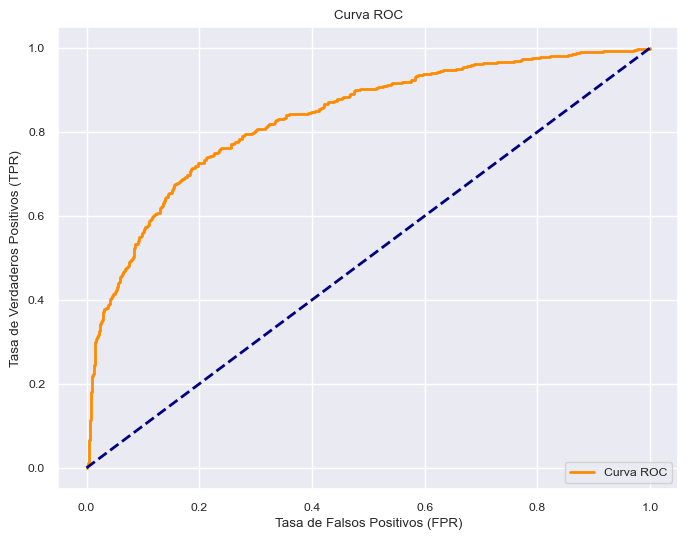

Área bajo la curva ROC = 0.8326104460311983


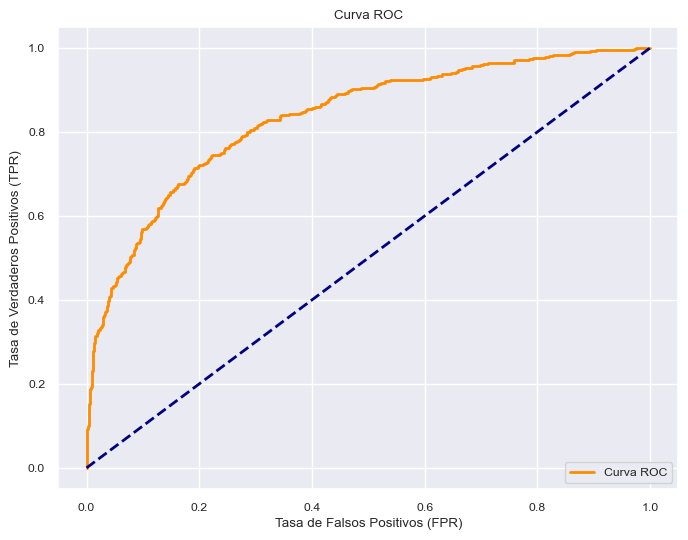

Área bajo la curva ROC = 0.8344172218830462


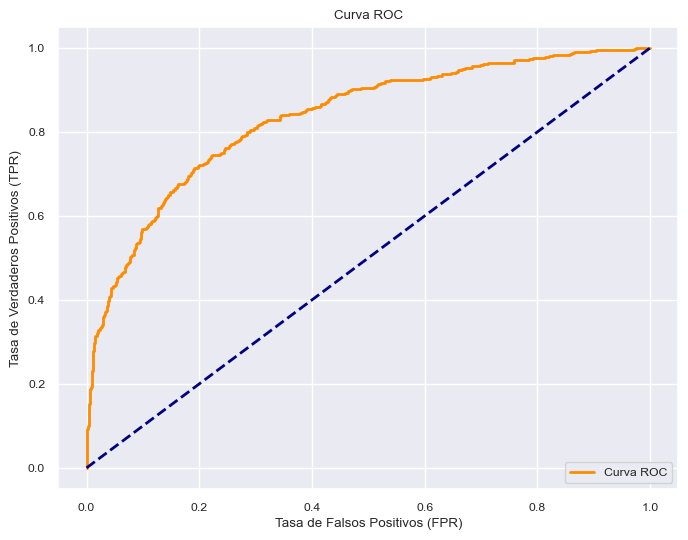

Área bajo la curva ROC = 0.8344172218830462


In [154]:
# Curva ROC de cada modelo candidato
AUC_ForwAIC = curva_roc(x_test_log_ForwAIC, y_test_glm, modeloLog_ForwAIC)
AUC_ForwBIC = curva_roc(x_test_log_ForwBIC, y_test_glm, modeloLog_ForwBIC)
AUC_BackAIC = curva_roc(x_test_log_BackAIC, y_test_glm, modeloLog_BackAIC)
AUC_BackBIC = curva_roc(x_test_log_BackBIC, y_test_glm, modeloLog_BackBIC)
AUC_StepAIC = curva_roc(x_test_log_StepAIC, y_test_glm, modeloLog_StepAIC)
AUC_StepBIC = curva_roc(x_test_log_StepBIC, y_test_glm, modeloLog_StepBIC)

In [155]:
# Validación cruzada repetida – AUC
results_glm = pd.DataFrame({'AUC': [], 'Resample': [], 'Modelo': []})

for rep in range(20):
    modelo1VC = validacion_cruzada_glm(5, x_train_glm, y_train_glm,
                    modeloLog_ForwAIC['Variables']['cont'], modeloLog_ForwAIC['Variables']['categ'])
    modelo2VC = validacion_cruzada_glm(5, x_train_glm, y_train_glm,
                    modeloLog_ForwBIC['Variables']['cont'], modeloLog_ForwBIC['Variables']['categ'])
    modelo3VC = validacion_cruzada_glm(5, x_train_glm, y_train_glm,
                    modeloLog_BackAIC['Variables']['cont'], modeloLog_BackAIC['Variables']['categ'])
    modelo4VC = validacion_cruzada_glm(5, x_train_glm, y_train_glm,
                    modeloLog_BackBIC['Variables']['cont'], modeloLog_BackBIC['Variables']['categ'])
    modelo5VC = validacion_cruzada_glm(5, x_train_glm, y_train_glm,
                    modeloLog_StepAIC['Variables']['cont'], modeloLog_StepAIC['Variables']['categ'])
    modelo6VC = validacion_cruzada_glm(5, x_train_glm, y_train_glm,
                    modeloLog_StepBIC['Variables']['cont'], modeloLog_StepBIC['Variables']['categ'])

    results_rep = pd.DataFrame({
        'AUC':     modelo1VC + modelo2VC + modelo3VC + modelo4VC + modelo5VC + modelo6VC,
        'Resample': ['Rep' + str(rep + 1)] * 5 * 6,
        'Modelo':   [1]*5 + [2]*5 + [3]*5 + [4]*5 + [5]*5 + [6]*5
    })
    results_glm = pd.concat([results_glm, results_rep], axis=0)

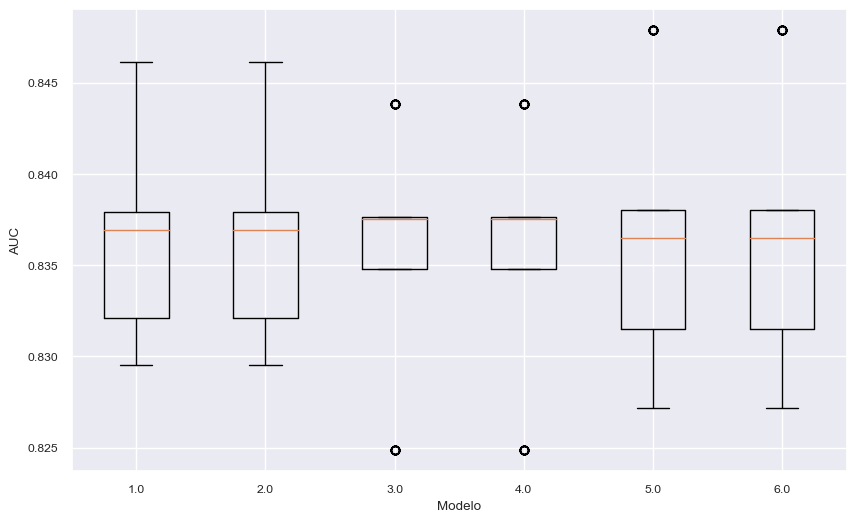

Modelo
1.0    0.836527
2.0    0.836527
3.0    0.835729
4.0    0.835729
5.0    0.836221
6.0    0.836221
Name: AUC, dtype: float64
Modelo
1.0    0.005730
2.0    0.005730
3.0    0.006219
4.0    0.006219
5.0    0.007003
6.0    0.007003
Name: AUC, dtype: float64
[79, 79, 76, 76, 75, 75]


In [164]:
# Boxplot validación cruzada
# Modelos: 1=ForwAIC, 2=ForwBIC, 3=BackAIC, 4=BackBIC, 5=StepAIC, 6=StepBIC
plt.figure(figsize=(10, 6))
plt.grid(True)
grupo_metrica = results_glm.groupby('Modelo')['AUC']
boxplot_data  = [grupo_metrica.get_group(g).tolist() for g in grupo_metrica.groups]
plt.boxplot(boxplot_data, labels=grupo_metrica.groups.keys())
plt.xlabel('Modelo')
plt.ylabel('AUC')
plt.show()

media_auc = results_glm.groupby('Modelo')['AUC'].mean()
std_auc   = results_glm.groupby('Modelo')['AUC'].std()
print(media_auc)
print(std_auc)

num_params_glm = [len(modeloLog_ForwAIC['Modelo'].coef_[0]), len(modeloLog_ForwBIC['Modelo'].coef_[0]),
                  len(modeloLog_BackAIC['Modelo'].coef_[0]), len(modeloLog_BackBIC['Modelo'].coef_[0]),
                  len(modeloLog_StepAIC['Modelo'].coef_[0]), len(modeloLog_StepBIC['Modelo'].coef_[0])]
print(num_params_glm)

In [166]:
# Modelo ganador logístico
ModeloGanadorGLM = modeloLog_ForwAIC

# summary_glm peta con CCAA + CodigoProvincia juntas (multicolinealidad perfecta → matriz singular)
# Se reajusta sin CCAA solo para mostrar el summary; las métricas del ganador no cambian
from FuncionesMineria import glm as glm_fit
var_cont_sum  = ModeloGanadorGLM['Variables']['cont']
var_categ_sum = [v for v in ModeloGanadorGLM['Variables']['categ'] if v != 'CCAA']

ModeloGanadorGLM_sum = glm_fit(y_train_glm, x_train_glm, var_cont_sum, var_categ_sum)
summary_glm(ModeloGanadorGLM_sum['Modelo'], y_train_glm, ModeloGanadorGLM_sum['X'])

{'Contrastes':                       Variable  Estimate  Std. Error   z value   p value  \
 0                  (Intercept)  5.938436    0.851770  6.971876  0.000000   
 1             SameComAutonPtge -0.029781    0.003561 -8.362254  0.000000   
 2                Explotaciones  0.000761    0.000183  4.167766  0.000031   
 3                Age_19_65_pct -0.029909    0.006530 -4.580122  0.000005   
 4          WomanPopulationPtge -0.038623    0.009938 -3.886266  0.000103   
 ..                         ...       ...         ...       ...       ...   
 59     ActividadPpal_Servicios -0.523352    0.148612 -3.521587  0.000432   
 60               Densidad_Baja -0.339602    0.165152 -2.056295  0.039794   
 61        Densidad_Desconocido -0.564220    0.327693 -1.721794  0.085155   
 62            Densidad_MuyBaja -0.769661    0.171921 -4.476832  0.000008   
 63  prop_missings_con_missings  0.203677    0.080728  2.523000  0.011660   
 
    signif  
 0     ***  
 1     ***  
 2     ***  
 3     *

In [175]:
resultado = summary_glm(ModeloGanadorGLM_sum['Modelo'], y_train_glm, ModeloGanadorGLM_sum['X'])
print(resultado['Contrastes'].to_string())
print(resultado['BondadAjuste'])

                        Variable  Estimate  Std. Error   z value   p value signif
0                    (Intercept)  5.938436    0.851770  6.971876  0.000000    ***
1               SameComAutonPtge -0.029781    0.003561 -8.362254  0.000000    ***
2                  Explotaciones  0.000761    0.000183  4.167766  0.000031    ***
3                  Age_19_65_pct -0.029909    0.006530 -4.580122  0.000005    ***
4            WomanPopulationPtge -0.038623    0.009938 -3.886266  0.000103    ***
5                     SUPERFICIE  0.000008    0.000004  2.164420  0.030469      *
6                  PobChange_pct -0.007695    0.003927 -1.959410  0.050108      .
7   ConstructionUnemploymentPtge  0.007219    0.003070  2.351092  0.018748      *
8                     Population  0.000044    0.000023  1.900389  0.057427      .
9             CodigoProvincia_10 -0.464215    0.405127 -1.145850  0.251900       
10            CodigoProvincia_11  1.825325    0.557121  3.276352  0.001057     **
11            Co

In [ ]:
# Modelo ganador logístico
#ModeloGanadorGLM = modeloLog_BackAIC

#summary_glm(ModeloGanadorGLM['Modelo'], y_train_glm, ModeloGanadorGLM['X'])

LinAlgError: Singular matrix

In [167]:
# Estabilidad train/test del modelo ganador
pseudoR2(ModeloGanadorGLM['Modelo'], ModeloGanadorGLM['X'], y_train_glm)

x_test_ganador_glm = crear_data_modelo(x_test_glm, ModeloGanadorGLM['Variables']['cont'],
                                                    ModeloGanadorGLM['Variables']['categ'],
                                                    ModeloGanadorGLM['Variables']['inter'])
pseudoR2(ModeloGanadorGLM['Modelo'], x_test_ganador_glm, y_test_glm)

Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619867
         Iterations 5


0.27689118262680346

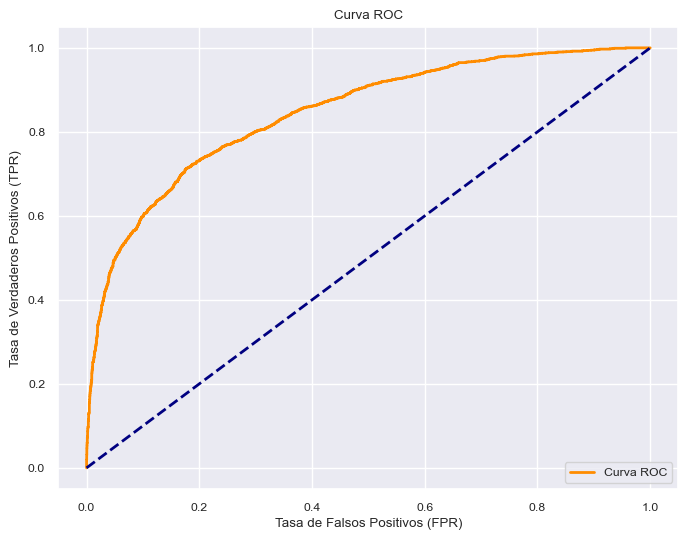

Área bajo la curva ROC = 0.8447478798200292


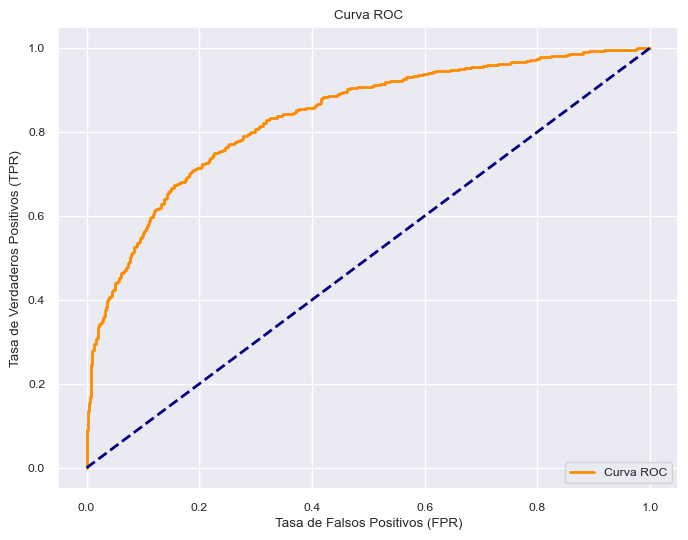

Área bajo la curva ROC = 0.8359178545200363


0.8359178545200363

In [168]:
# Curva ROC train y test del modelo ganador
curva_roc(crear_data_modelo(x_train_glm, ModeloGanadorGLM['Variables']['cont'],
                                          ModeloGanadorGLM['Variables']['categ'],
                                          ModeloGanadorGLM['Variables']['inter']),
          y_train_glm, ModeloGanadorGLM)

curva_roc(x_test_ganador_glm, y_test_glm, ModeloGanadorGLM)

Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620104
  

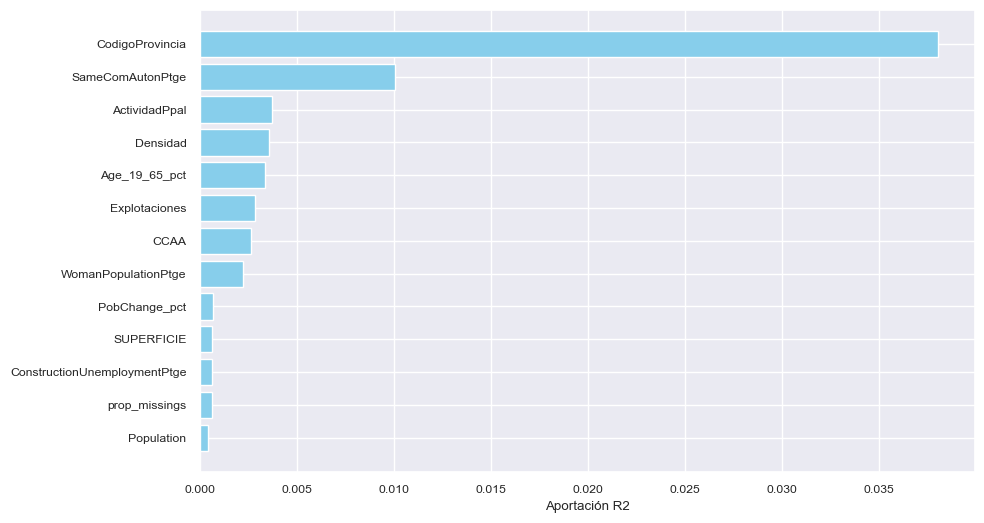

,Variables,R2
7,Population,0.000439
12,prop_missings,0.000650
6,ConstructionUnemploymentPtge,0.000654
4,SUPERFICIE,0.000659
5,PobChange_pct,0.000662
3,WomanPopulationPtge,0.002256
11,CCAA,0.002667
1,Explotaciones,0.002873
2,Age_19_65_pct,0.003360
10,Densidad,0.003556


In [169]:
# Importancia de variables del modelo ganador
impVariablesLog(ModeloGanadorGLM, y_train_glm, x_train_glm,
                ModeloGanadorGLM['Variables']['cont'],
                ModeloGanadorGLM['Variables']['categ'],
                ModeloGanadorGLM['Variables']['inter'])

### 8.2 Punto de corte óptimo

In [170]:
# Rejilla de puntos de corte
posiblesCortes = np.arange(0, 1.01, 0.01).tolist()

rejilla = pd.DataFrame({
    'PtoCorte': [], 'Accuracy': [], 'Sensitivity': [],
    'Specificity': [], 'PosPredValue': [], 'NegPredValue': []
})

for pto_corte in posiblesCortes:
    rejilla = pd.concat(
        [rejilla, sensEspCorte(ModeloGanadorGLM['Modelo'], x_test_glm, y_test_glm,
                               pto_corte,
                               ModeloGanadorGLM['Variables']['cont'],
                               ModeloGanadorGLM['Variables']['categ'],
                               ModeloGanadorGLM['Variables']['inter'])],
        axis=0
    )

rejilla['Youden'] = rejilla['Sensitivity'] + rejilla['Specificity'] - 1
rejilla.index = list(range(len(rejilla)))

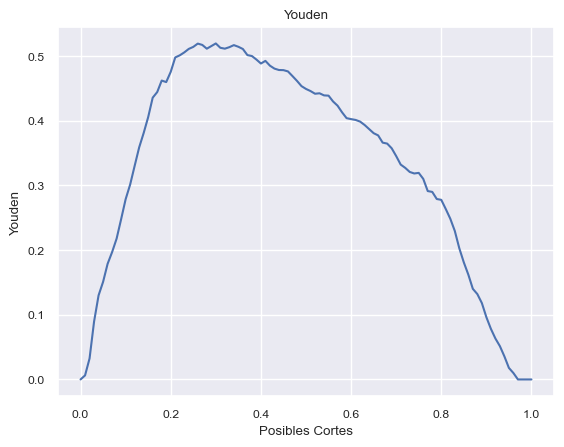

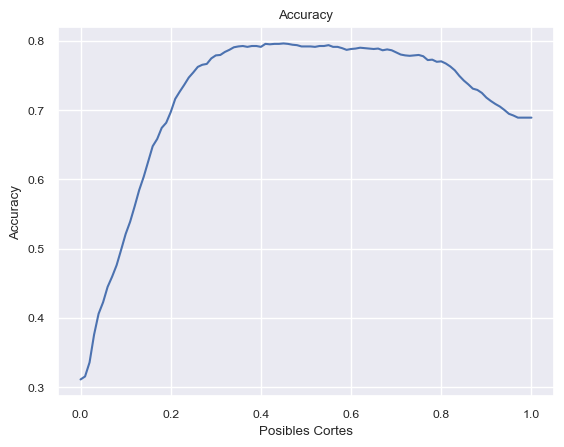

Punto de corte óptimo Youden:   0.3
Punto de corte óptimo Accuracy: 0.45


In [171]:
plt.plot(rejilla['PtoCorte'], rejilla['Youden'])
plt.xlabel('Posibles Cortes')
plt.ylabel('Youden')
plt.title('Youden')
plt.show()

plt.plot(rejilla['PtoCorte'], rejilla['Accuracy'])
plt.xlabel('Posibles Cortes')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.show()

pto_youden   = rejilla['PtoCorte'][rejilla['Youden'].idxmax()]
pto_accuracy = rejilla['PtoCorte'][rejilla['Accuracy'].idxmax()]

print('Punto de corte óptimo Youden:  ', pto_youden)
print('Punto de corte óptimo Accuracy:', pto_accuracy)

In [172]:
# Métricas para ambos puntos de corte
sensEspCorte(ModeloGanadorGLM['Modelo'], x_test_glm, y_test_glm,
             pto_youden,
             ModeloGanadorGLM['Variables']['cont'],
             ModeloGanadorGLM['Variables']['categ'],
             ModeloGanadorGLM['Variables']['inter'])

,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.3,0.778941,0.708911,0.810545,0.62807,0.860531


In [173]:
sensEspCorte(ModeloGanadorGLM['Modelo'], x_test_glm, y_test_glm,
             pto_accuracy,
             ModeloGanadorGLM['Variables']['cont'],
             ModeloGanadorGLM['Variables']['categ'],
             ModeloGanadorGLM['Variables']['inter'])

,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.45,0.796182,0.588119,0.89008,0.707143,0.827243


**TODO:** elegir el punto de corte óptimo y justificarlo según el objetivo.

### 8.3 Interpretación de coeficientes

In [174]:
# Coeficientes del modelo ganador con odds ratio
coeficientes = pd.DataFrame({
    'Variable':    ModeloGanadorGLM['X'].columns,
    'Coeficiente': ModeloGanadorGLM['Modelo'].coef_[0]
})
coeficientes['OddsRatio'] = np.exp(coeficientes['Coeficiente'])
coeficientes.sort_values('Coeficiente', key=abs, ascending=False)

,Variable,Coeficiente,OddsRatio
70,CCAA_ComValenciana,-2.138605,0.117819
9,CodigoProvincia_11,1.876405,6.529985
69,CCAA_Cataluña,1.853019,6.379046
41,CodigoProvincia_40,-1.659019,0.190326
20,CodigoProvincia_21,1.522321,4.582850
...,...,...,...
5,PobChange_pct,-0.008905,0.991135
6,ConstructionUnemploymentPtge,0.007542,1.007570
1,Explotaciones,0.000837,1.000837
7,Population,0.000045,1.000045
